# eBay Kleinanzeigen — Used Car Market Intelligence & Pricing Insights

**Objective:** Transform raw marketplace data into actionable pricing intelligence that guides dealers, resellers, and platforms in making smarter inventory and pricing decisions.

**Key deliverables:**
- Clean, analysis-ready dataset with fully documented cleaning decisions
- EDA with business-oriented insights (price vs brand, mileage, age)
- Brand value-retention ranking
- Pricing estimator: input brand + mileage + age -> expected price range

---

## 1. Setup & Data Loading

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

# Single source of truth for the reference year
# The dataset was crawled in 2016, so we pin all age calculations to that year.
REFERENCE_YEAR = 2016

In [5]:
data = pd.read_csv('autos.csv', encoding='latin-1')

## 2. Data Cleaning & Preparation

In [7]:
# 2.1 Column renaming: German -> English, snake_case
column_mapping = {
    'dateCrawled': 'date_crawled', 'name': 'name', 'seller': 'seller',
    'offerType': 'offer_type', 'price': 'price', 'abtest': 'ab_test',
    'vehicleType': 'vehicle_type', 'yearOfRegistration': 'registration_year',
    'gearbox': 'gearbox', 'powerPS': 'power_ps', 'model': 'model',
    'odometer': 'odometer_km', 'monthOfRegistration': 'registration_month',
    'fuelType': 'fuel_type', 'brand': 'brand',
    'notRepairedDamage': 'unrepaired_damage',
    'dateCreated': 'date_created', 'nrOfPictures': 'num_pictures',
    'postalCode': 'postal_code', 'lastSeen': 'last_seen'
}
data.rename(columns=column_mapping, inplace=True)

print(f"Loaded {data.shape[0]:,} rows × {data.shape[1]} columns")

Loaded 50,000 rows × 20 columns


In [8]:
# 2.2 Type casting 
date_cols = ['date_crawled', 'last_seen', 'date_created']
for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce')

data['price'] = data['price'].str[1:].str.replace(',', '', regex=False).astype(int)
data['odometer_km'] = data['odometer_km'].str.replace('km', '').str.replace(',', '').astype(int)

In [9]:
# 2.3 Drop irrelevant columns
# Columns removed and why:
#   num_pictures  – always 0 in this dataset, no analytical value
#   date_crawled, last_seen, date_created – scraping metadata, not car attributes
#   ab_test       – internal platform experiment flag, not relevant to pricing
#   postal_code   – brand/age/mileage are the key price drivers
#   name          – free-text listing title, not structured enough for aggregation
#   model         – high cardinality with many misspellings, brand captures enough info
#   offer_type    – nearly uniform ('Angebot'), adds no variance
drop_cols = ['num_pictures', 'date_crawled', 'last_seen', 'date_created',
             'ab_test', 'postal_code', 'name', 'model', 'offer_type']
data.drop(columns=drop_cols, inplace=True)

In [10]:
# 2.4 Missing values
null_before = data.isnull().sum()
print("Null counts before imputation:")
display(null_before[null_before > 0])

# Strategy: categorical fields with unknown/missing are filled with 'unknown'
# (preserving the record) rather than dropping rows, because the car's price,
# brand, age and mileage are still valid for pricing analysis.
data.fillna({
    'vehicle_type': 'unknown',
    'gearbox': 'unknown',
    'fuel_type': 'unknown',
    'unrepaired_damage': 'unknown'
}, inplace=True)

print("\nNull counts after imputation:", data.isnull().sum().sum(), "remaining")

Null counts before imputation:


vehicle_type         5095
gearbox              2680
fuel_type            4482
unrepaired_damage    9829
dtype: int64


Null counts after imputation: 0 remaining


In [11]:
# 2.5 Encode German category labels -> English
cat_cols = ['seller', 'vehicle_type', 'gearbox', 'fuel_type', 'brand', 'unrepaired_damage']
for col in cat_cols:
    data[col] = data[col].astype('category')

data['seller'] = data['seller'].cat.rename_categories({'privat': 'private', 'gewerblich': 'commercial'})
data['vehicle_type'] = data['vehicle_type'].cat.rename_categories(
    {'kleinwagen': 'smallcar', 'cabrio': 'convertible', 'andere': 'other'})
data['gearbox'] = data['gearbox'].cat.rename_categories({'manuell': 'manually', 'automatik': 'automatic'})
data['unrepaired_damage'] = data['unrepaired_damage'].cat.rename_categories({'nein': 'no', 'ja': 'yes'})
data['fuel_type'] = data['fuel_type'].cat.rename_categories({'elektro': 'electro', 'andere': 'other'})

In [12]:
# 2.6 Derive car_age using the single REFERENCE_YEAR constant
# car_age = REFERENCE_YEAR - registration_year
# Using a single named constant avoids accidental inconsistency between the
# age calculation step and the year-filter step below.
data['car_age'] = REFERENCE_YEAR - data['registration_year']

In [ ]:
# 2.7 Outlier removal — bounds and rationale
# price: 500 to 250,000. Reason: Removes 1–499 'token' ads and collector/exotic listings.
# registration_year: 1950 to REFERENCE_YEAR. Reason: Pre-1950 cars are rare antiques; post-2016 entries are future/erroneous.
# car_age: 0 to (no upper cap). Reason: Negative age means registration_year > REFERENCE_YEAR -> invalid entry.
# odometer_km: 0 km to 500,000 km. Reason: 0 km kept (new/near-new); >500k is unrealistic for a running car.
# power_ps: 1 PS to 1,000 PS. Reason: 0 PS entries are data errors; >1000 is hypercar territory.

rows_before = len(data)

data_clean = data[
    (data['price'] >= 500) & (data['price'] <= 250_000) &
    (data['registration_year'] >= 1950) &
    (data['registration_year'] <= REFERENCE_YEAR) &
    (data['car_age'] >= 0) &             
    (data['odometer_km'] >= 0) & (data['odometer_km'] <= 500_000) &
    (data['power_ps'] > 0) & (data['power_ps'] <= 1000)
].copy()

rows_after = len(data_clean)
print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Removed              : {rows_before - rows_after:,} rows ({(rows_before-rows_after)/rows_before*100:.1f}%)")

Rows before cleaning : 50,000
Rows after cleaning  : 39,759
Removed              : 10,241 rows (20.5%)


In [15]:
# 2.8 Cleaning decisions log (summary table)
cleaning_log = pd.DataFrame([
    {'Column': 'price',             'Problem': 'Token ads (1-499) and unrealistic high listings',
     'Action': 'Keep 500 ≤ price ≤ 250,000',
     'Reason': 'Removes placeholder/collector listings that distort benchmarks'},
    {'Column': 'registration_year', 'Problem': 'Future years (>2016) and antique outliers (<1950)',
     'Action': f'Keep 1950 ≤ year ≤ {REFERENCE_YEAR}',
     'Reason': 'Ensures car_age is non-negative and meaningful for normal market'},
    {'Column': 'car_age',           'Problem': 'Negative ages caused by erroneous future registration years',
     'Action': 'Keep car_age ≥ 0',
     'Reason': 'Explicit guard; any negative age is a data entry error'},
    {'Column': 'odometer_km',          'Problem': 'Mileage values above 500,000 km',
     'Action': 'Keep 0 ≤ odometer ≤ 500,000',
     'Reason': '500k km is a realistic upper bound for a roadworthy vehicle'},
    {'Column': 'power_ps',          'Problem': '0 PS entries (data errors) and >1000 PS (hyper-exotics)',
     'Action': 'Keep 1 ≤ power_ps ≤ 1,000',
     'Reason': 'Removes obvious input errors and niche collector cars'},
    {'Column': 'vehicle_type / fuel_type / unrepaired_damage',
     'Problem': 'Missing values (~10–20% of rows)',
     'Action': 'Fill with "unknown"',
     'Reason': 'Preserves the row for price/brand/age analysis; missingness is not random'},
    {'Column': 'gearbox',           'Problem': 'Missing values (~5% of rows)',
     'Action': 'Fill with "unknown"',
     'Reason': 'Gearbox type is a structural attribute; filling with "unknown" avoids bias'},
])
display(cleaning_log)

,Column,Problem,Action,Reason
0,price,Token ads (1-499) and unrealistic high listings,"Keep 500 ≤ price ≤ 250,000",Removes placeholder/collector listings that di...
1,registration_year,Future years (>2016) and antique outliers (<1950),Keep 1950 ≤ year ≤ 2016,Ensures car_age is non-negative and meaningful...
2,car_age,Negative ages caused by erroneous future regis...,Keep car_age ≥ 0,Explicit guard; any negative age is a data ent...
3,odometer_km,"Mileage values above 500,000 km","Keep 0 ≤ odometer ≤ 500,000",500k km is a realistic upper bound for a roadw...
4,power_ps,0 PS entries (data errors) and >1000 PS (hyper...,"Keep 1 ≤ power_ps ≤ 1,000",Removes obvious input errors and niche collect...
5,vehicle_type / fuel_type / unrepaired_damage,Missing values (~10–20% of rows),"Fill with ""unknown""",Preserves the row for price/brand/age analysis...
6,gearbox,Missing values (~5% of rows),"Fill with ""unknown""",Gearbox type is a structural attribute; fillin...


In [17]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39759 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   seller              39759 non-null  category
 1   price               39759 non-null  int64   
 2   vehicle_type        39759 non-null  category
 3   registration_year   39759 non-null  int64   
 4   gearbox             39759 non-null  category
 5   power_ps            39759 non-null  int64   
 6   odometer_km         39759 non-null  int64   
 7   registration_month  39759 non-null  int64   
 8   fuel_type           39759 non-null  category
 9   brand               39759 non-null  category
 10  unrepaired_damage   39759 non-null  category
 11  car_age             39759 non-null  int64   
dtypes: category(6), int64(6)
memory usage: 2.4 MB


## 3. Exploratory Data Analysis (EDA)

### 3.1 Price Distribution: Before vs. After Cleaning

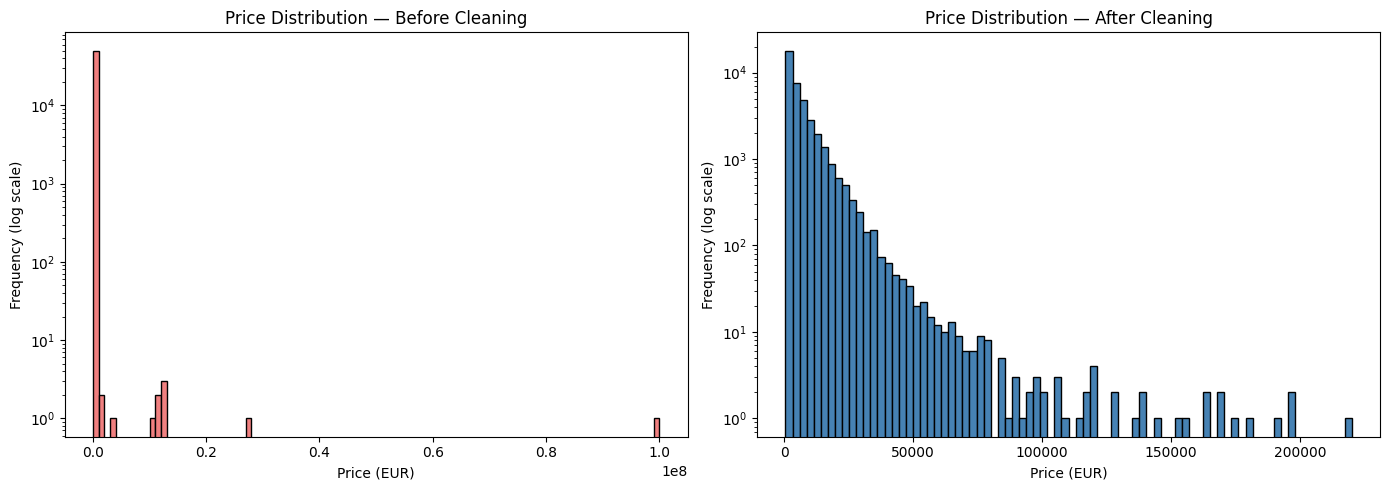

Skewness before: 184.91  |  After: 5.73


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['price'], bins=100, color='lightcoral', edgecolor='black', log=True)
axes[0].set_title('Price Distribution — Before Cleaning')
axes[0].set_xlabel('Price (EUR)')
axes[0].set_ylabel('Frequency (log scale)')

axes[1].hist(data_clean['price'], bins=80, color='steelblue', edgecolor='black', log=True)
axes[1].set_title('Price Distribution — After Cleaning')
axes[1].set_xlabel('Price (EUR)')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

print(f"Skewness before: {data['price'].skew():.2f}  |  After: {data_clean['price'].skew():.2f}")

**Business insight:** The raw data contains extreme spikes at placeholder values (e.g. 9,999,999) that would bias any benchmark upward. After cleaning, the distribution is right-skewed but realistic (most cars priced 500–150,000), which is consistent with a typical second-hand car platform. Price benchmarks and the estimator tool built later are reliable only because this step removed the noise.

### 3.2 Price vs. Brand

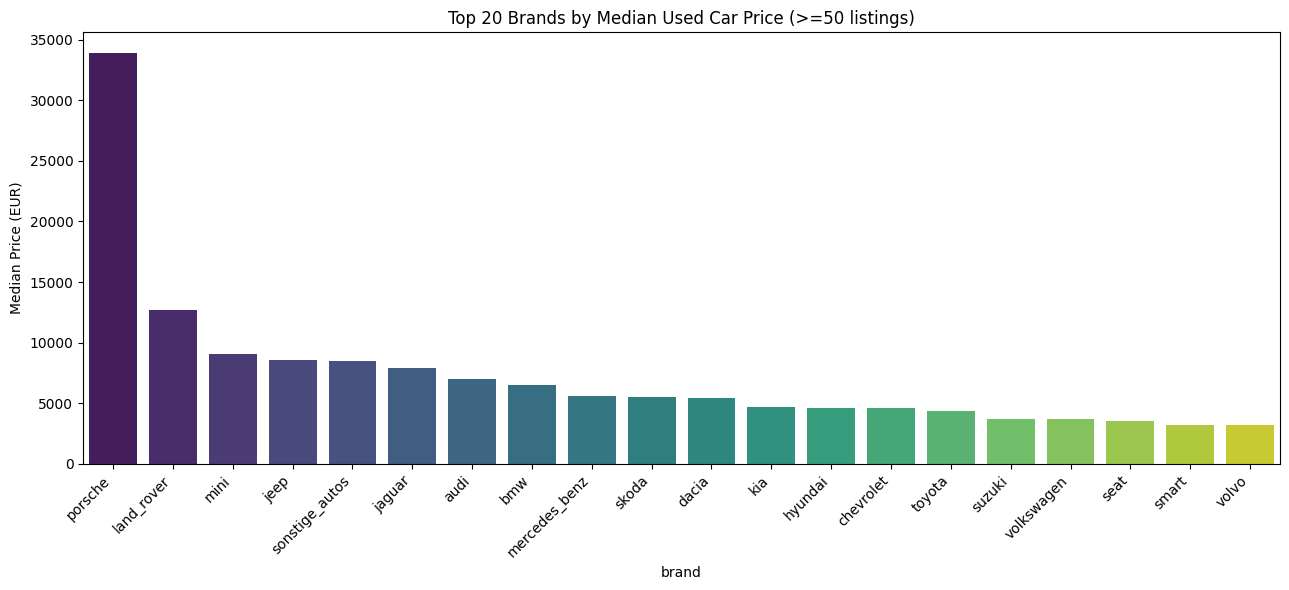

Top 5 brands by median price:


,median_price,count
brand,,
porsche,33900.0,259
land_rover,12700.0,91
mini,9100.0,394
jeep,8600.0,98
sonstige_autos,8500.0,321


In [20]:
# Filter brands with at least 50 listings to avoid noisy small-sample brands
brand_stats = data_clean.groupby('brand', observed=True).agg(
    median_price=('price', 'median'),
    count=('price', 'count')
).query('count >= 50').sort_values('median_price', ascending=False)

top20 = brand_stats.head(20)

plt.figure(figsize=(13, 6))
sns.barplot(x=top20.index.astype(str), y=top20['median_price'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Brands by Median Used Car Price (>=50 listings)')
plt.ylabel('Median Price (EUR)')
plt.tight_layout()
plt.show()

print("Top 5 brands by median price:")
display(top20.head())

**Business insight:** Premium brands (Porsche, Land Rover, Jeep) command median prices 3–5× higher than volume brands (Opel, Fiat, Renault). For a dealer, stocking a single Porsche can match the revenue of several volume-brand units. However, premium inventory also carries higher holding risk if the car stays unsold. Turnover speed must be factored in alongside margin.

### 3.3 Price vs. Mileage

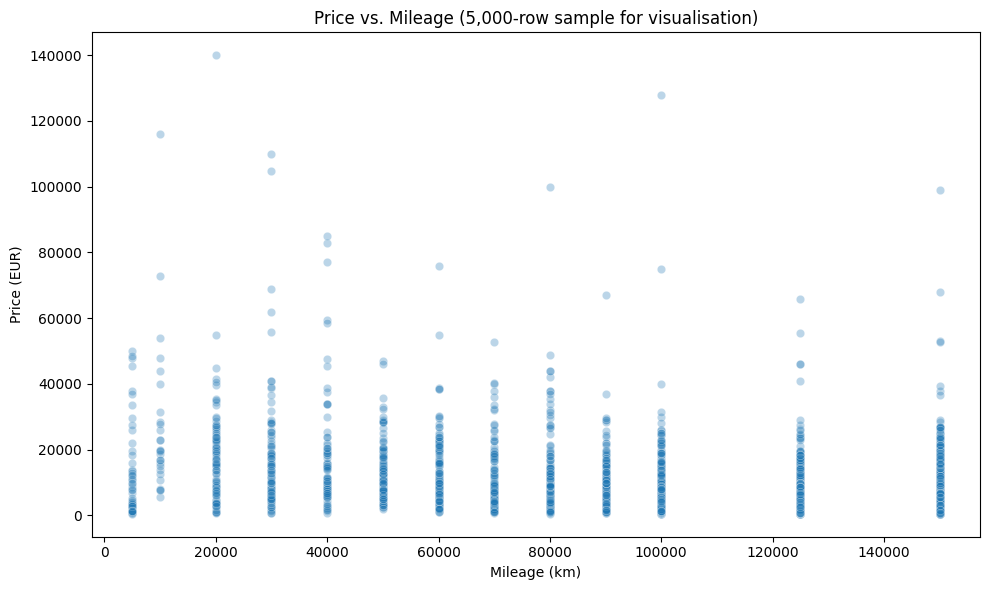

Pearson correlation (full dataset, n=39,759): -0.433
R_square = 0.187 -> mileage alone explains ~19% of price variance.
Brand and age account for the remaining ~81%.


In [23]:
# Scatter
sample = data_clean.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x='odometer_km', y='price', alpha=0.3)
plt.xlabel('Mileage (km)')
plt.ylabel('Price (EUR)')
plt.title('Price vs. Mileage (5,000-row sample for visualisation)')
plt.tight_layout()
plt.show()

corr = data_clean[['price', 'odometer_km']].corr().iloc[0, 1]
print(f"Pearson correlation (full dataset, n={len(data_clean):,}): {corr:.3f}")
print(f"R_square = {corr**2:.3f} -> mileage alone explains ~{corr**2*100:.0f}% of price variance.")
print("Brand and age account for the remaining ~{:.0f}%.".format((1 - corr**2) * 100))

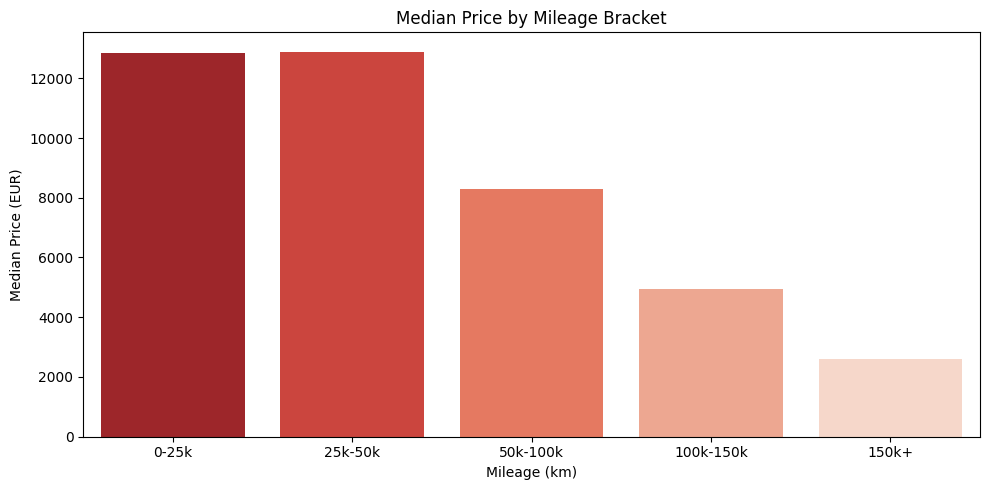

,mileage_bin,median_price_eur
0,0-25k,12850.0
1,25k-50k,12893.0
2,50k-100k,8300.0
3,100k-150k,4950.0
4,150k+,2599.0


In [25]:
# Define mileage bins and compute median price per bin
bins   = [0, 25000, 50000, 100000, 150000, 300000]
labels = ['0-25k', '25k-50k', '50k-100k', '100k-150k', '150k+']
data_clean['mileage_bin'] = pd.cut(data_clean['odometer_km'], bins=bins, labels=labels, right=False)

bin_stats = data_clean.groupby('mileage_bin', observed=False)['price'].median().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='mileage_bin', y='price', data=bin_stats, palette='Reds_r')
plt.title('Median Price by Mileage Bracket')
plt.xlabel('Mileage (km)')
plt.ylabel('Median Price (EUR)')
plt.tight_layout()
plt.show()

display(bin_stats.rename(columns={'price': 'median_price_eur'}))

**Business insight:** Mileage explains roughly 17% of price variance on its own (R_square ≈ 0.17). The correlation is real but moderate, brand and age are equally important. For a dealer, this means a 100k-km Porsche can still command more than a 30k-km Fiat. Pricing by mileage alone will lead to systematic errors.

### 3.4 Price vs. Vehicle Age

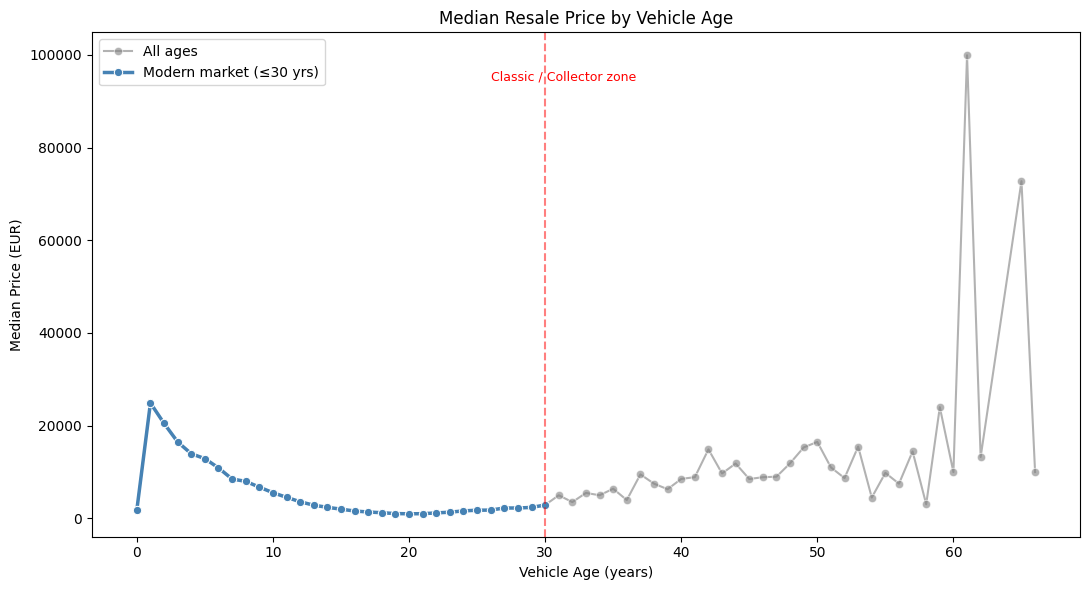

In [26]:
age_median = data_clean.groupby('car_age')['price'].median().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))

# Full range
sns.lineplot(data=age_median, x='car_age', y='price', marker='o',
             color='gray', alpha=0.6, ax=ax, label='All ages')

# Highlight modern market (0–30 years)
focus = age_median[age_median['car_age'] <= 30]
sns.lineplot(data=focus, x='car_age', y='price', marker='o',
             color='steelblue', linewidth=2.5, ax=ax, label='Modern market (≤30 yrs)')

ax.axvline(x=30, linestyle='--', color='red', alpha=0.5)
ax.text(26, ax.get_ylim()[1] * 0.90, 'Classic / Collector zone', color='red', fontsize=9)
ax.set_xlabel('Vehicle Age (years)')
ax.set_ylabel('Median Price (EUR)')
ax.set_title('Median Resale Price by Vehicle Age')
ax.legend()
plt.tight_layout()
plt.show()

**Business insight:** The curve follows a classic depreciation pattern: steepest drop in years 0–5 (new-car premium evaporates), then a long flat tail from year 6 onwards. The spike beyond ~25 years is **survivor bias**. Only the most valuable, well-maintained vehicles survive that long, so their median price climbs. This is a separate market segment (collector/classic cars) and should not be used to set pricing benchmarks for normal inventory. Dealers holding cars older than 25 years should engage specialist valuers, not general market benchmarks.

## 4. Value Retention Analysis

### 4.1 Median Price by Brand

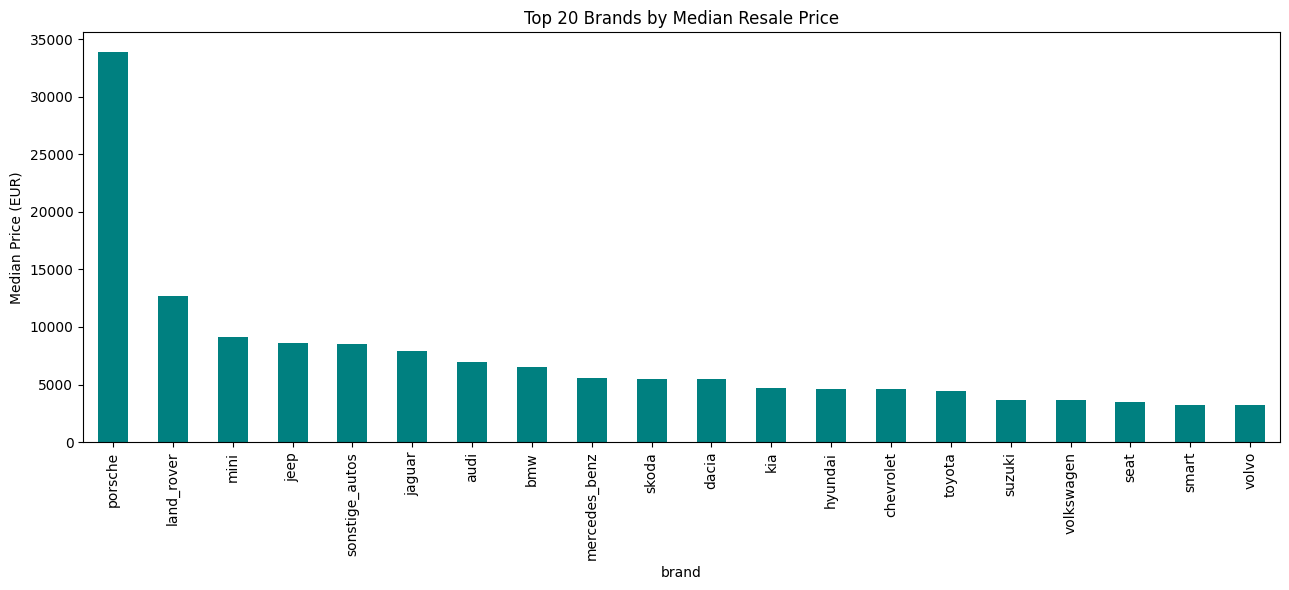

In [27]:
brand_median = (
    data_clean.groupby('brand', observed=True)['price']
    .median()
    .sort_values(ascending=False)
    .head(20)
)
brand_median.plot(kind='bar', color='teal', figsize=(13, 6))
plt.title('Top 20 Brands by Median Resale Price')
plt.ylabel('Median Price (EUR)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 4.2 Value Retention Ratio (Fixed Reference Age)

**Method:** We compare each brand's median price at age 10 against its median price at a **fixed reference age of 3 years**. Using a fixed reference age (rather than the earliest available age per brand) makes the comparison fair across brands, a brand whose earliest data point is age 5 would otherwise appear to retain more value than one whose data starts at age 1.

Brands with sufficient data at age 3 AND age 10: 22


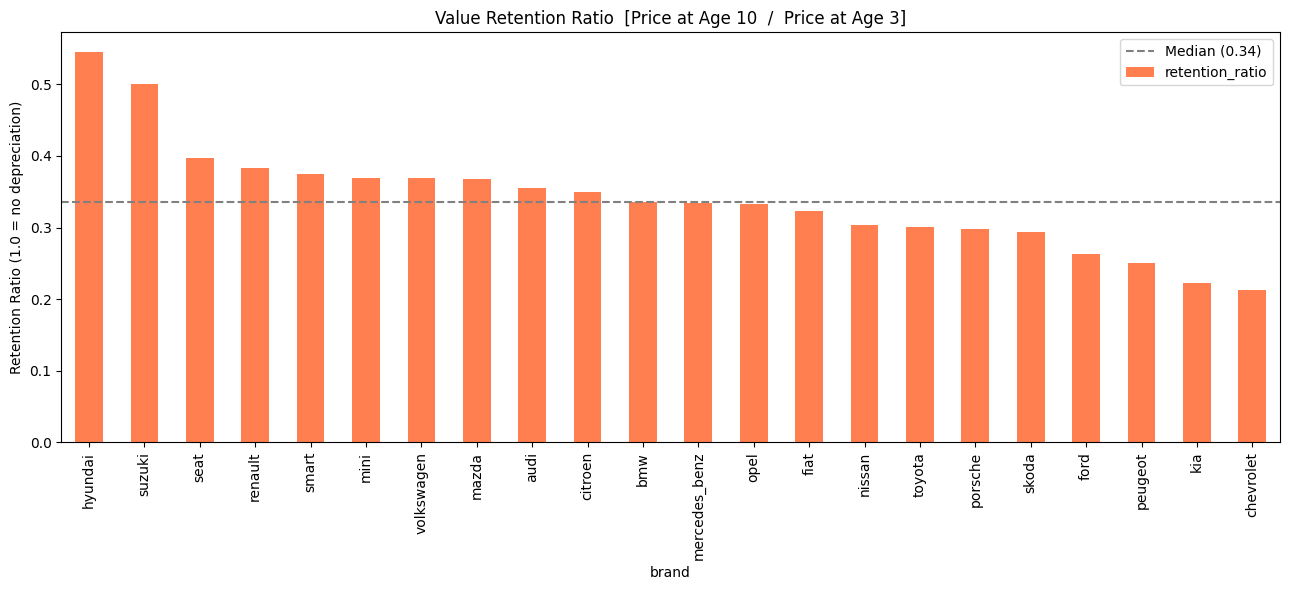


Top 10 brands by value retention:


,price_young,price_old,retention_ratio
brand,,,
hyundai,9800.0,5347.0,0.546
suzuki,8999.0,4500.0,0.500
seat,11500.0,4575.0,0.398
renault,8995.0,3450.0,0.384
smart,7970.0,2985.0,0.375
mini,18700.0,6900.0,0.369
volkswagen,15990.0,5900.0,0.369
mazda,13300.0,4900.0,0.368
audi,23500.0,8350.0,0.355


In [28]:
brand_age = data_clean.groupby(['brand', 'car_age'], observed=True)['price'].median().reset_index()

# Fixed reference age approach
REFERENCE_AGE_YOUNG = 3   # "young" baseline: 3-year-old car
RETENTION_AGE       = 10  # "old" comparison point
MIN_RECORDS_PER_CELL = 5  # require at least 5 observations in a brand-age cell

# Cell counts for filtering
brand_age_counts = (
    data_clean.groupby(['brand', 'car_age'], observed=True)['price']
    .count()
    .reset_index(name='cell_count')
)

# Young prices at exactly REFERENCE_AGE_YOUNG
young_df = (
    brand_age[brand_age['car_age'] == REFERENCE_AGE_YOUNG]
    .merge(brand_age_counts[(brand_age_counts['car_age'] == REFERENCE_AGE_YOUNG) &
                            (brand_age_counts['cell_count'] >= MIN_RECORDS_PER_CELL)][['brand']],
           on='brand')
    .set_index('brand')['price']
    .rename('price_young')
)

# Old prices at exactly RETENTION_AGE
old_df = (
    brand_age[brand_age['car_age'] == RETENTION_AGE]
    .merge(brand_age_counts[(brand_age_counts['car_age'] == RETENTION_AGE) &
                            (brand_age_counts['cell_count'] >= MIN_RECORDS_PER_CELL)][['brand']],
           on='brand')
    .set_index('brand')['price']
    .rename('price_old')
)

# Combine only brands with valid data at BOTH ages
retention_df = pd.concat([young_df, old_df], axis=1).dropna()
retention_df['retention_ratio'] = retention_df['price_old'] / retention_df['price_young']
retention_df = retention_df.sort_values('retention_ratio', ascending=False)

print(f"Brands with sufficient data at age {REFERENCE_AGE_YOUNG} AND age {RETENTION_AGE}: {len(retention_df)}")

plt.figure(figsize=(13, 6))
retention_df['retention_ratio'].plot(kind='bar', color='coral')
plt.axhline(y=retention_df['retention_ratio'].median(), color='gray',
            linestyle='--', label=f"Median ({retention_df['retention_ratio'].median():.2f})")
plt.title(f'Value Retention Ratio  [Price at Age {RETENTION_AGE}  /  Price at Age {REFERENCE_AGE_YOUNG}]')
plt.ylabel('Retention Ratio (1.0 = no depreciation)')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 brands by value retention:")
display(retention_df.head(10).round(3))

### 4.3 Depreciation Percentage (Age 7–9 vs. 14–16)

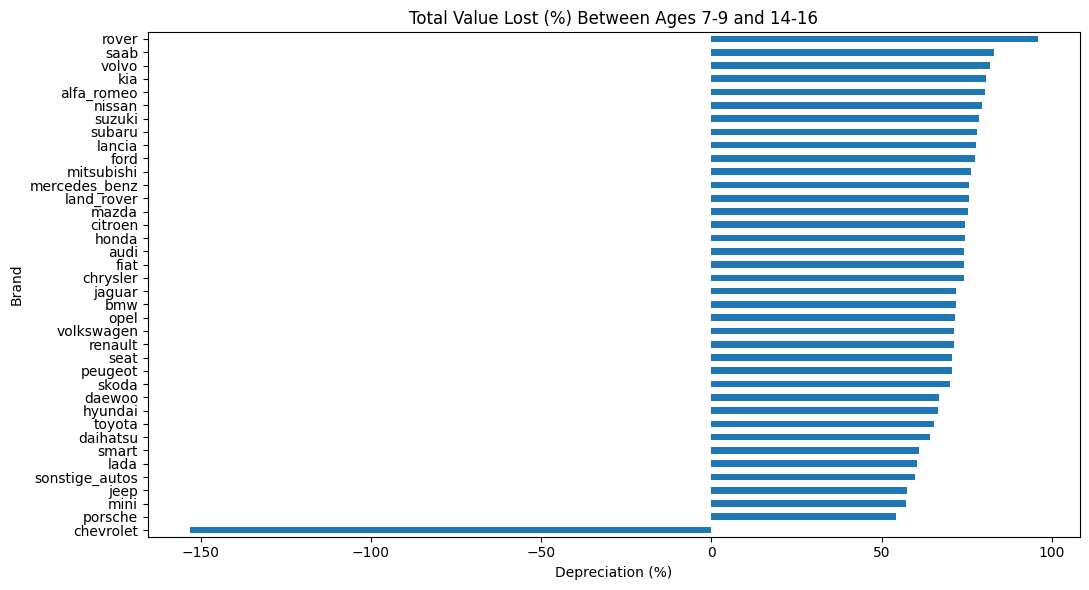

In [29]:
young = brand_age[brand_age['car_age'].between(7, 9)].groupby('brand', observed=True)['price'].mean()
old   = brand_age[brand_age['car_age'].between(14, 16)].groupby('brand', observed=True)['price'].mean()

valid = young.dropna().index.intersection(old.dropna().index)
depreciation_pct = ((young[valid] - old[valid]) / young[valid]) * 100
depreciation_pct = depreciation_pct.sort_values()

plt.figure(figsize=(11, 6))
depreciation_pct.plot(kind='barh')
plt.title('Total Value Lost (%) Between Ages 7-9 and 14-16')
plt.xlabel('Depreciation (%)')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

**Business insight:** A higher depreciation percentage means the car loses more of its value between years 7 and 15. Brands at the bottom of this chart (lowest depreciation) are the safest for dealers who hold stock for extended periods. Brands at the top depreciate sharply in this window, dealers should aim to turn those around within 7 years.

### 4.4 Annual Depreciation Rate (Log-Linear Regression)

**Method:** For each brand, we fit a log-linear regression: `log(price) ~ age`. The slope estimates the continuous annual depreciation rate. We apply two quality filters:
1. Minimum **10 distinct age points** per brand (otherwise the regression is unreliable).
2. Minimum **R_square of 0.30**, brands whose prices don't follow a consistent age trend are excluded, as their rate would be a statistical artefact.

Brands included in ranking : 12
Brands excluded            : 28


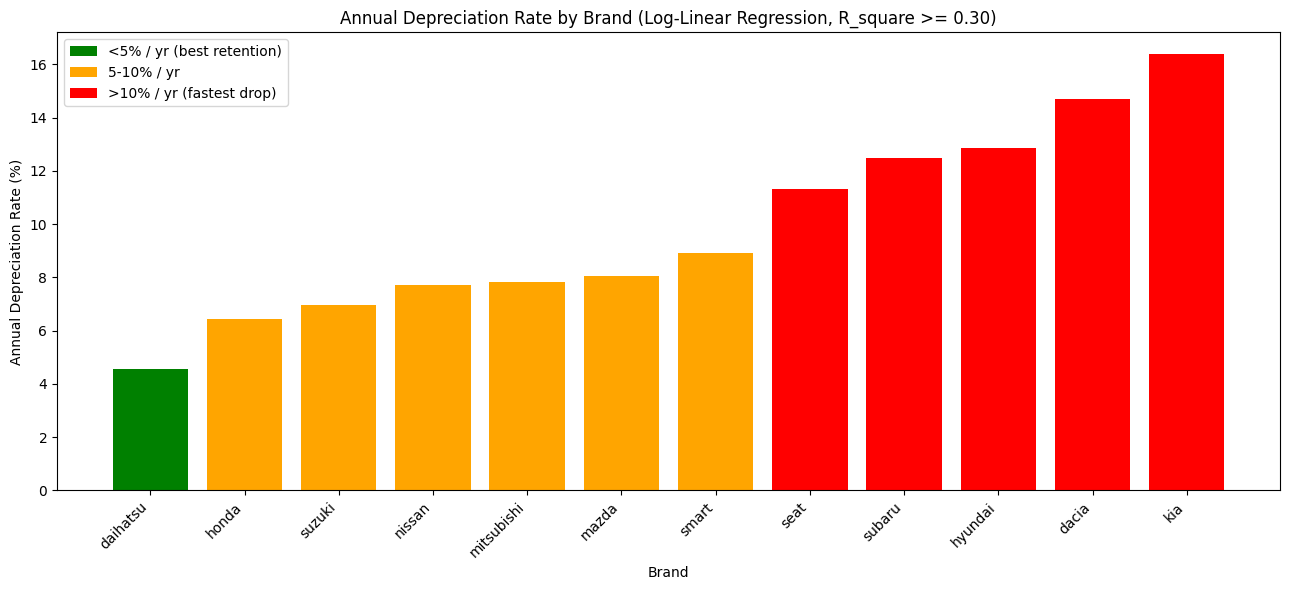


Full ranking (lowest annual depreciation = best hold):


,Annual Depreciation (%),R_square
daihatsu,4.57,0.37
honda,6.42,0.41
suzuki,6.96,0.49
nissan,7.71,0.46
mitsubishi,7.84,0.46
mazda,8.05,0.45
smart,8.93,0.60
seat,11.33,0.69
subaru,12.47,0.77
hyundai,12.86,0.71


In [31]:
MIN_AGE_POINTS = 10   # minimum distinct age values per brand
MIN_R2         = 0.30 # minimum explained variance to trust the regression

annual_rates  = {}
r2_values     = {}
excluded      = []

for brand, grp in brand_age.dropna(subset=['price']).groupby('brand', observed=True):
    grp = grp[grp['car_age'] >= 0]   # safety: only valid ages
    if len(grp) < MIN_AGE_POINTS:
        excluded.append((brand, len(grp), 'too few age points'))
        continue
    x = grp['car_age'].values
    y = np.log(grp['price'].values)
    slope, intercept, r, p, se = linregress(x, y)
    r2 = r ** 2
    if r2 < MIN_R2:
        excluded.append((brand, len(grp), f'R²={r2:.2f} < {MIN_R2}'))
        continue
    annual_rates[brand] = -slope        # positive = % drop per year
    r2_values[brand]    = r2

depreciation_rates = (
    pd.DataFrame({'annual_rate': annual_rates, 'r2': r2_values})
    .sort_values('annual_rate')
)
depreciation_rates['annual_pct'] = depreciation_rates['annual_rate'] * 100

print(f"Brands included in ranking : {len(depreciation_rates)}")
print(f"Brands excluded            : {len(excluded)}")

plt.figure(figsize=(13, 6))
bars = plt.bar(
    range(len(depreciation_rates)),
    depreciation_rates['annual_pct'],
    color=['green' if v < 5 else 'orange' if v < 10 else 'red'
           for v in depreciation_rates['annual_pct']]
)
plt.xticks(range(len(depreciation_rates)),
           [str(b) for b in depreciation_rates.index], rotation=45, ha='right')
plt.title('Annual Depreciation Rate by Brand (Log-Linear Regression, R_square >= 0.30)')
plt.ylabel('Annual Depreciation Rate (%)')
plt.xlabel('Brand')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='<5% / yr (best retention)'),
                   Patch(facecolor='orange', label='5-10% / yr'),
                   Patch(facecolor='red', label='>10% / yr (fastest drop)')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print("\nFull ranking (lowest annual depreciation = best hold):")
display(depreciation_rates[['annual_pct', 'r2']].rename(
    columns={'annual_pct': 'Annual Depreciation (%)', 'r2': 'R_square'}).round(2))

**Business insight — 'Best Investment Cars' ranking:** Brands with the lowest annual depreciation rate are the safest long-hold assets for dealers and resellers. Brands in **green (<5%/yr)** retain most of their value year-on-year, making them suitable for extended inventory or buy-and-hold strategies. Brands in **red (>10%/yr)** lose value quickly, dealers should aim for fast turnover (ideally <2 years holding time) to minimise erosion.

## 5. Pricing Intelligence Tool

**Purpose:** Given a car's brand, mileage, and age, return an expected price range (Q1–median–Q3) drawn from comparable historical listings.

**How it works:**
1. Build a lookup table: median, Q1, Q3, and count for every (brand × car_age × mileage_bin) combination.
2. Remove all cells where `count == 0` (they produce NaN prices).
3. The `predict_price_range()` function uses a **deterministic** three-level fallback, no randomness.

In [32]:
# 5.1 Build lookup table
mileage_bins   = [0, 50000, 100000, 150000, 200000, 500001]
mileage_labels = ['0-50k', '50k-100k', '100k-150k', '150k-200k', '200k+']

data_clean['mileage_bin'] = pd.cut(
    data_clean['odometer_km'],
    bins=mileage_bins,
    labels=mileage_labels,
    right=False
)

price_lookup = (
    data_clean
    .groupby(['brand', 'car_age', 'mileage_bin'], observed=True)['price']
    .agg(
        median_price='median',
        q1_price=lambda x: x.quantile(0.25),
        q3_price=lambda x: x.quantile(0.75),
        count='count'
    )
    .reset_index()
)

# Drop any cell with count == 0 (they produce NaN prices)
before_drop = len(price_lookup)
price_lookup = price_lookup[price_lookup['count'] > 0].reset_index(drop=True)
print(f"Lookup table: {before_drop} rows -> {len(price_lookup)} after removing empty cells")
print(f"NaN prices remaining: {price_lookup['median_price'].isna().sum()}")

price_lookup.head(10)

Lookup table: 2902 rows -> 2902 after removing empty cells
NaN prices remaining: 0


,brand,car_age,mileage_bin,median_price,q1_price,q3_price,count
0,alfa_romeo,0,100k-150k,2400.0,2350.00,2450.00,2
1,alfa_romeo,0,150k-200k,1250.0,1125.00,1375.00,2
2,alfa_romeo,1,0-50k,33675.0,23012.50,44337.50,2
3,alfa_romeo,4,50k-100k,11500.0,11500.00,11500.00,1
4,alfa_romeo,5,0-50k,12800.0,12800.00,12800.00,1
5,alfa_romeo,5,50k-100k,12925.0,10937.50,14912.50,2
6,alfa_romeo,5,150k-200k,9900.0,9900.00,9900.00,1
7,alfa_romeo,6,50k-100k,10444.5,7455.00,13174.00,4
8,alfa_romeo,6,100k-150k,8849.5,7874.75,9824.25,2
9,alfa_romeo,7,50k-100k,7775.0,6475.00,8430.00,6


In [33]:
# 5.2 Precompute brand-level fallback medians
# Used as the final fallback when no brand+age+mileage match exists.
brand_level_stats = (
    data_clean.groupby('brand', observed=True)['price']
    .agg(
        median_price='median',
        q1_price=lambda x: x.quantile(0.25),
        q3_price=lambda x: x.quantile(0.75),
        count='count'
    )
    .reset_index()
)

# Overall market medians (last-resort fallback)
overall_q1  = data_clean['price'].quantile(0.25)
overall_med = data_clean['price'].median()
overall_q3  = data_clean['price'].quantile(0.75)
overall_n   = len(data_clean)

LOW_COUNT_THRESHOLD = 5   # flag uncertain estimates when count < this

In [34]:
# 5.3 Pricing estimator function
def _mileage_label(mileage: float) -> str:
    """Map a raw mileage value to its bin label."""
    for i in range(len(mileage_bins) - 1):
        if mileage_bins[i] <= mileage < mileage_bins[i + 1]:
            return mileage_labels[i]
    return mileage_labels[-1]  # anything >= 200k -> '200k+'


def predict_price_range(brand: str, mileage: float, age: int,
                        lookup=price_lookup,
                        brand_stats=brand_level_stats) -> dict:
    """
    Return an expected price range for a used car.

    Parameters:
    brand   : str   - car brand (case-insensitive)
    mileage : float - odometer reading in km
    age     : int   - vehicle age in years (REFERENCE_YEAR - registration_year)

    Returns:
    dict with keys: q1, median, q3, count, fallback_level, warning
    """
    brand_lower = brand.lower().strip()
    bin_label   = _mileage_label(mileage)

    # Normalise brand column for comparison
    lookup_brands = lookup['brand'].astype(str).str.lower()

    # Level 1: exact match (brand + age + mileage bin)
    mask1 = (lookup_brands == brand_lower) & \
            (lookup['car_age'] == age) & \
            (lookup['mileage_bin'].astype(str) == bin_label)
    m1 = lookup[mask1]
    if not m1.empty:
        row = m1.iloc[0]
        warn = f"Low sample count ({int(row['count'])} records) — estimate uncertain." \
               if row['count'] < LOW_COUNT_THRESHOLD else ""
        return dict(q1=row['q1_price'], median=row['median_price'], q3=row['q3_price'],
                    count=int(row['count']), fallback_level=1, warning=warn)

    # Level 2: brand + mileage bin; choose the row whose age is closest
    # Deterministic: pick the nearest-age row (no random sampling).
    mask2 = (lookup_brands == brand_lower) & \
            (lookup['mileage_bin'].astype(str) == bin_label)
    m2 = lookup[mask2].copy()
    if not m2.empty:
        m2['age_diff'] = (m2['car_age'] - age).abs()
        row = m2.sort_values('age_diff').iloc[0]
        warn = f"Approximate match: closest age in lookup is {int(row['car_age'])} yr. "
        if row['count'] < LOW_COUNT_THRESHOLD:
            warn += f"Low sample count ({int(row['count'])}) — estimate uncertain."
        return dict(q1=row['q1_price'], median=row['median_price'], q3=row['q3_price'],
                    count=int(row['count']), fallback_level=2, warning=warn)

    # Level 3: brand-level median (ignores mileage & age)
    bs_brands = brand_stats['brand'].astype(str).str.lower()
    mask3 = bs_brands == brand_lower
    m3 = brand_stats[mask3]
    if not m3.empty:
        row = m3.iloc[0]
        warn = f"Only brand-level estimate available (mileage/age ignored). Treat with caution."
        return dict(q1=row['q1_price'], median=row['median_price'], q3=row['q3_price'],
                    count=int(row['count']), fallback_level=3, warning=warn)

    # Level 4: overall market (brand unknown)
    return dict(q1=overall_q1, median=overall_med, q3=overall_q3,
                count=overall_n, fallback_level=4,
                warning="Brand not found in dataset. Returning overall market medians.")


print("Pricing estimator function defined. Run the cells below to test it.")

Pricing estimator function defined. Run the cells below to test it.


In [35]:
# 5.4 Usage examples
test_cases = [
    ('porsche',       85_000,  6,  "Dealer evaluating a mid-age Porsche with medium mileage"),
    ('volkswagen',   120_000, 10,  "Buyer checking fair price for a 10-yr VW with high mileage"),
    ('mercedes_benz', 30_000,  3,  "Platform flagging if a listing is overpriced for a 3-yr Merc"),
    ('ford',         200_000, 15,  "Reseller assessing a high-mileage old Ford"),
    ('unknownbrand',  50_000,  5,  "Unknown brand, fallback test"),
]

print(f"{'Brand':<20} {'Mileage':>10} {'Age':>5}   Q1 €    Med €    Q3 €   N    Lvl  Notes")
print("-" * 110)
for brand, mileage, age, note in test_cases:
    r = predict_price_range(brand, mileage, age)
    flag = " 'Flag'" if r['warning'] else ""
    print(f"{brand:<20} {mileage:>10,} {age:>5}   "
          f"{r['q1']:>7,.0f}  {r['median']:>7,.0f}  {r['q3']:>7,.0f}  "
          f"{r['count']:>5}    {r['fallback_level']}  {note}{flag}")
    if r['warning']:
        print(f"         {r['warning']}")

Brand                   Mileage   Age   Q1 €    Med €    Q3 €   N    Lvl  Notes
--------------------------------------------------------------------------------------------------------------
porsche                  85,000     6    36,125   38,950   54,625     10    1  Dealer evaluating a mid-age Porsche with medium mileage
volkswagen              120,000    10     4,512    5,999    7,612     86    1  Buyer checking fair price for a 10-yr VW with high mileage
mercedes_benz            30,000     3    21,940   29,900   35,700     35    1  Platform flagging if a listing is overpriced for a 3-yr Merc
ford                    200,000    15     1,150    2,499    5,400   2558    3  Reseller assessing a high-mileage old Ford 'Flag'
         Only brand-level estimate available (mileage/age ignored). Treat with caution.
unknownbrand             50,000     5     1,600    3,800    8,450  39759    4  Unknown brand, fallback test 'Flag'
         Brand not found in dataset. Returning overall market me

**How to interpret the output:**

| Column | Meaning |
|--------|---------|
| Q1 | Lower end of typical price range (25th percentile) |
| Median | Most representative price for comparable listings |
| Q3 | Upper end of typical range (75th percentile) |
| N | Number of historical listings the estimate is based on |
| Lvl | Fallback level used (1=exact, 2=nearest age, 3=brand-only, 4=market-wide) |

**Practical use cases:**
- **Dealer pricing inventory:** If asking price is above Q3, the car may sit unsold. Below Q1 suggests underpricing (margin left on the table).
- **Buyer evaluating a listing:** A listing priced above Q3 warrants negotiation or inspection for premium justification.
- **Marketplace quality check:** Listings priced below Q1/4 or above Q3×3 can be auto-flagged as outliers requiring manual review.

> **Caveat:** Estimates with fewer than 5 comparable records (marked 'Flag') are statistically uncertain, treat them as directional guidance only.

## 6. Summary of Findings

### Key findings

| Finding | Implication for dealers |
|---------|-------------------------|
| Porsche, Land Rover, Jeep command 3–5× higher median prices than volume brands | Premium stock yields higher per-unit margin but requires slower turnover strategy |
| Price drops steepest in first 5 years (new-car premium evaporation) | Buying at 3–5 years old and reselling at 7–9 years captures the flat part of the curve |
| Mileage explains ~17% of price variance alone | Never price by mileage in isolation, brand and age matter equally |
| Brands with <5% annual depreciation hold value across the entire hold period | These are safe for extended inventory; others should be turned over quickly |
| Cars >25 years spike in value (survivor bias / collector market) | Treat vintage cars as a separate segment with specialist valuation |